In [10]:
import numpy as np

from ml_tools.models.layers.mixture_layers import PoolingLayer
from ml_tools.models.layers.operators import LatentStack, LatentSum
from ml_tools.models.model_loss import MSELoss
from ml_tools.models.optimizers import SGD
from ml_tools.models.layers.layers import (
    FrequencyFFT,
    FullyConnectedLayer,
    DropoutLayer,
    NormalizeLayer,
    RMSNormLayer
)
from ml_tools.models.layers.mixture_layers import PoolingLayer
from ml_tools.models.blocks import SpectreAttention, CausalSpectreAttention
from ml_tools.models.embedding.positional import SinusoidEmbedding

from ml_tools.models.neural_network import NeuralNetwork
import matplotlib.pyplot as plt

MAX_POSSIBLE_WINDOWS = 5000


In [11]:
from ml_tools.encoders.audio_encoders import AudioProcessor, read_wav, window_size_from_ms, plot_waveform, plot_spectrogram, plot_window_spectra, build_windows

WINDOW_LENGTH_MS = 20 # our window length
sample_rate, waveform_l = read_wav("../test.wav", channel=0)
sample_rate, waveform_r = read_wav("../test.wav", channel=1)

time_per_sample = 1000 / sample_rate
samples_per_window = window_size_from_ms(sample_rate, WINDOW_LENGTH_MS)
# samples_per_window = WINDOW_LENGTH_MS / time_per_sample
real_positive_fft_shape = (samples_per_window // 2) + 1


print(time_per_sample, "ms per sample step")
print(f"Each {WINDOW_LENGTH_MS} ms window will be composed of {samples_per_window} samples")
print(f"Fourier Transform will yield {real_positive_fft_shape} frequency bins")

audio_enc = AudioProcessor(
    sample_rate=sample_rate,
    window_ms = WINDOW_LENGTH_MS,
    overlap_ratio= 1/3, # how much of the window is overlapping with previous step
    use_decibels = True,
    target = "waveform",
    variable_idx = 0
)


encoded_data = audio_enc.fit_encode(waveform_l)
print(audio_enc.metadata)
print("amplitude", encoded_data["amplitude"].shape, "\nfrequency spectrum:", encoded_data["spectrum"].shape)


0.010416666666666666 ms per sample step
Each 20 ms window will be composed of 1920 samples
Fourier Transform will yield 961 frequency bins
{'target': 'waveform', 'variable_idx': 0, 'sample_rate': 96000, 'window_ms': 20, 'window_size': 1920, 'num_overlap': 640, 'num_frequencies': 575639, 'use_decibels': True}
amplitude (599, 1920) 
frequency spectrum: (599, 961)


/Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/encoders/audio_encoders.py:41: WavFileWarning: Chunk (non-data) not understood, skipping it.
  sample_rate, waveform = wavfile.read(file_path)


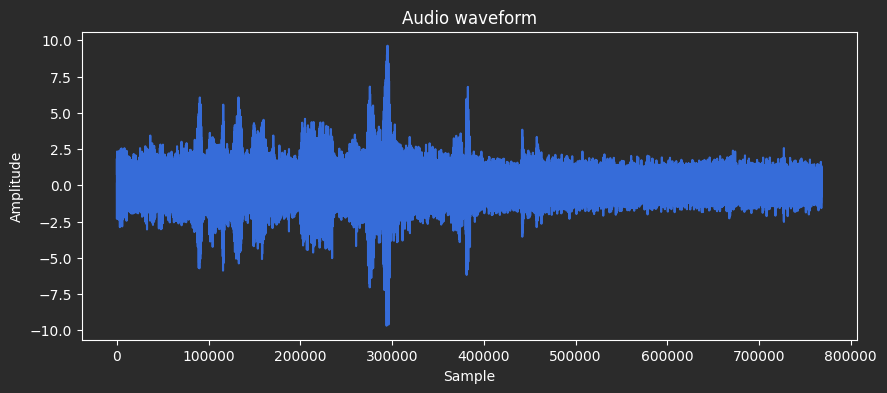

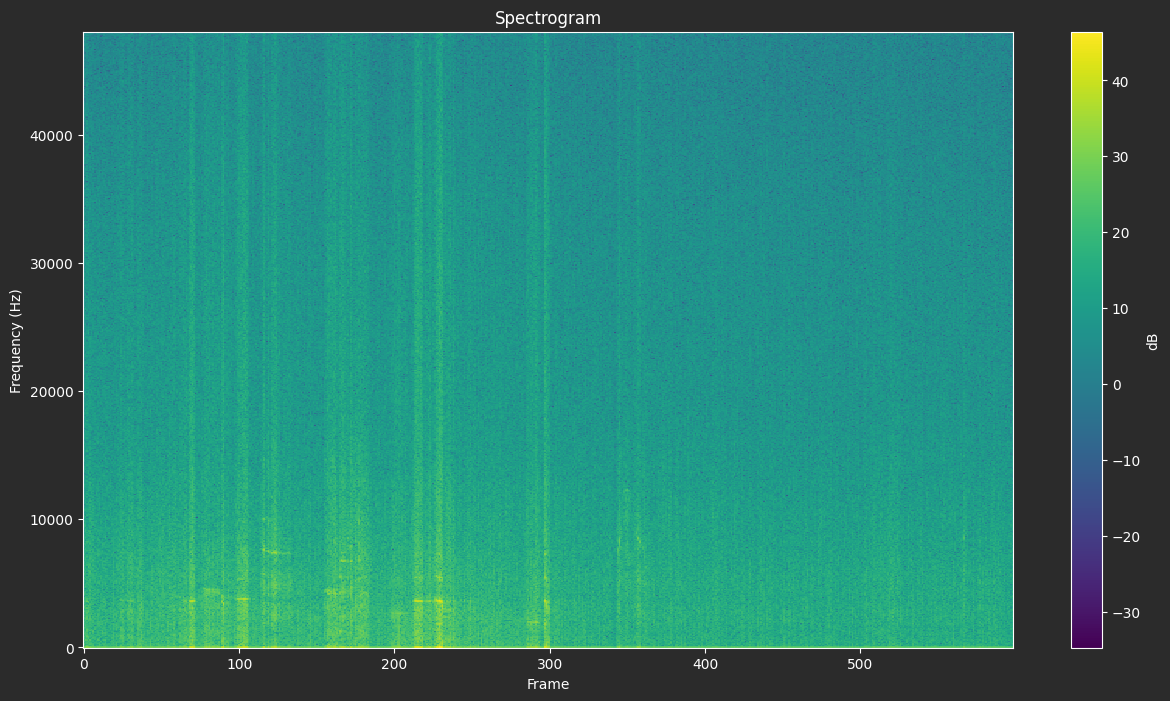

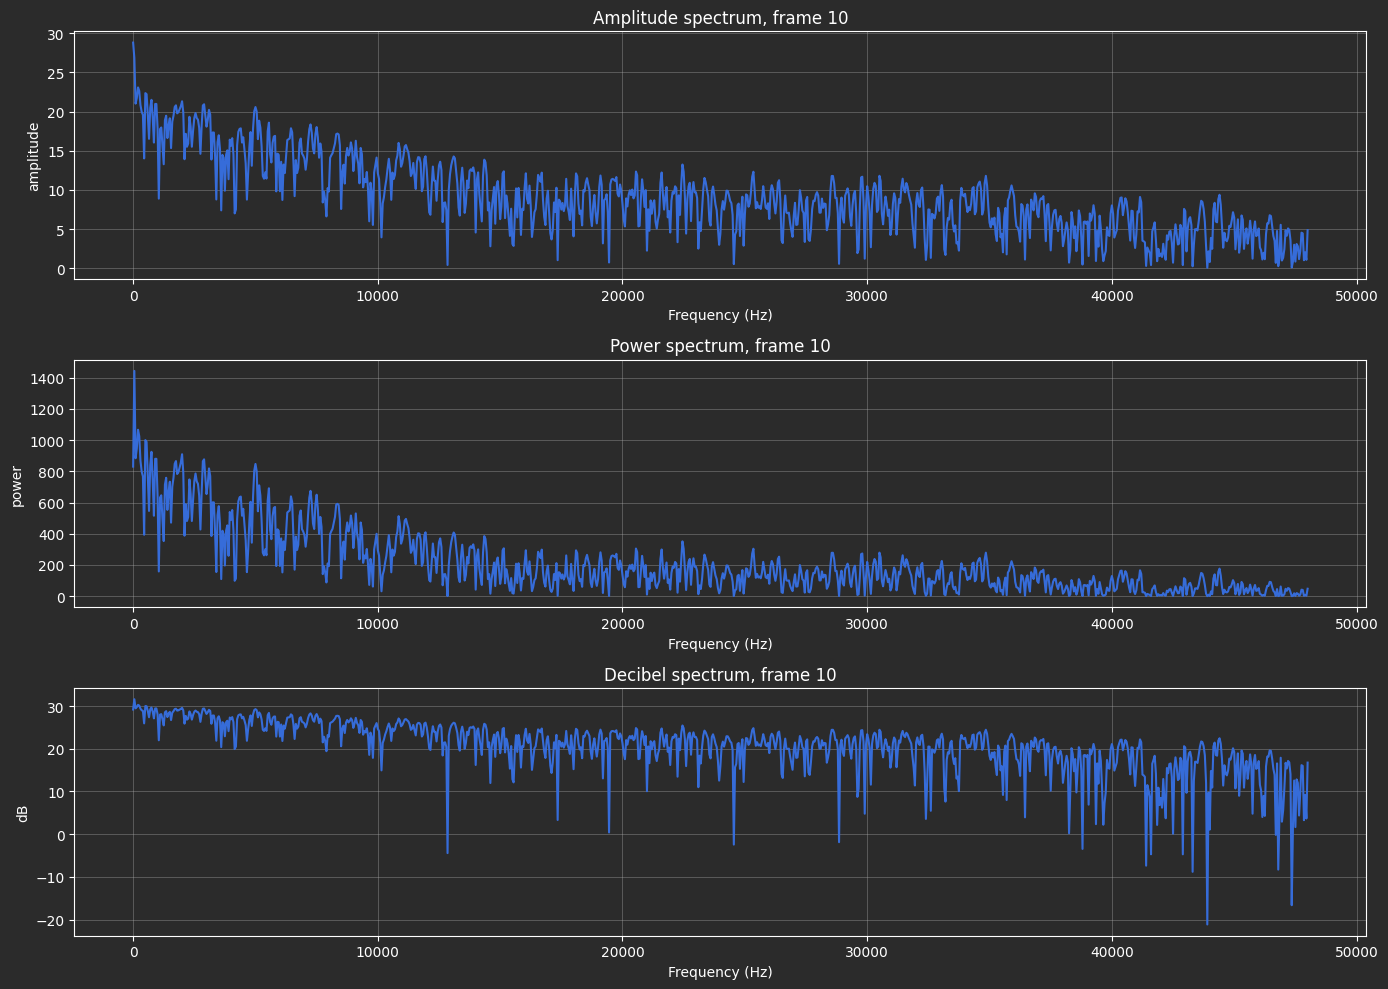

In [12]:
plot_waveform(waveform_l)
plot_spectrogram(encoded_data["spectrum"].real, audio_enc.freqs)
plot_window_spectra(
        encoded_data["spectrum"].real, audio_enc.freqs, index=10, window_size=time_per_sample
    )


In [13]:
# data will be (batch, num_windows, ms_window)

encoded_data = audio_enc.fit_encode(np.vstack([waveform_l, waveform_r]))
LATENT_DIMENSION = 1200

In [14]:
print(time_per_sample, samples_per_window)
print(waveform_l.shape)
print("amplitude", encoded_data["amplitude"].shape, "\nfrequency spectrum:", encoded_data["spectrum"].shape)

0.010416666666666666 1920
(768000,)
amplitude (2, 599, 1920) 
frequency spectrum: (2, 599, 961)


In [15]:
num_windows = 50
LATENT_DIMENSION = 2500
EMBEDDING_DIM = 1500
windowed_data = encoded_data["amplitude"][:, :num_windows, ...]

In [16]:
windowed_data.shape

(2, 50, 1920)

In [8]:
from ml_tools.models.neural_network import Node, NeuralNetwork
%pdb on
# TODO: fuse the encoder into the input object?
net = NeuralNetwork(name="audio_encoder_decoder", input_shape=((samples_per_window,),))
windows = net.input

# amplitude branch: funnel the raw window down to the latent width
amplitude = net.connect(FullyConnectedLayer(samples_per_window, 1200, "relu"), windows, name="amp_a")
amplitude = net.connect(FullyConnectedLayer(1200, real_positive_fft_shape, "relu"), amplitude, name="amp_b")
amplitude = net.connect(FullyConnectedLayer(real_positive_fft_shape, LATENT_DIMENSION, "tanh"), amplitude, name="amp_c")

# frequency branch. `windows` is used a second time here, which is the fan-out
frequency = net.connect(FrequencyFFT(num_windows, samples_per_window), windows, name="freq_fft")
frequency = net.connect(FullyConnectedLayer(samples_per_window, LATENT_DIMENSION, "tanh"), frequency, name="freq_fc")

# the branches merge, then get positional information
mixed = net.connect(LatentStack(), amplitude, frequency, name="stack")
mixed = net.connect(SinusoidEmbedding(num_windows, 2 * LATENT_DIMENSION), mixed, name="position")
mixed = net.connect(FullyConnectedLayer(2*LATENT_DIMENSION, LATENT_DIMENSION, "relu"), mixed, name="project")

# encoder

enc1 = net.connect(SpectreAttention(sequence_length=num_windows, hidden_dim=LATENT_DIMENSION), mixed, name="enc1_attn")
enc1 = net.connect(DropoutLayer(dropout_prob=0.05), enc1, name="enc1_drop")
enc1 = net.connect(FullyConnectedLayer(LATENT_DIMENSION, LATENT_DIMENSION, "relu"), enc1, name="enc1_a")

# encoder2 ------------------
enc2 = net.connect(LatentSum(), mixed, enc1, name="enc2_latentconn")
enc2 = net.connect(RMSNormLayer(ni=LATENT_DIMENSION), enc2, name="enc2_prenorm")
enc2 = net.connect(SpectreAttention(sequence_length=num_windows, hidden_dim=LATENT_DIMENSION), enc1, name="enc2_attn")
enc2 = net.connect(DropoutLayer(dropout_prob=0.05), enc2, name="enc2_drop")
enc2 = net.connect(FullyConnectedLayer(LATENT_DIMENSION, LATENT_DIMENSION, "relu"), enc2, name="enc2_a")


# # # encoder3 ------------------
enc3 = net.connect(LatentSum(), mixed, enc2, name="enc3_latentconn")
enc2 = net.connect(RMSNormLayer(ni=LATENT_DIMENSION), enc3, name="enc3_prenorm")
enc3 = net.connect(SpectreAttention(sequence_length=num_windows, hidden_dim=LATENT_DIMENSION), enc2, name="enc3_attn")
enc3 = net.connect(DropoutLayer(dropout_prob=0.05), enc3, name="enc3_drop")
enc3 = net.connect(FullyConnectedLayer(LATENT_DIMENSION, LATENT_DIMENSION, "relu"), enc3, name="enc3_a")

#
mixed = net.connect(RMSNormLayer(LATENT_DIMENSION), enc3, name="latent_norm")
latent = net.connect(FullyConnectedLayer(LATENT_DIMENSION, EMBEDDING_DIM, "tanh"), mixed, name="latent")
pooler = net.connect(PoolingLayer(), latent, name="pooler")

# decoder
decoded = net.connect(CausalSpectreAttention(sequence_length=, hidden_dim=, num_heads=8) pooler, name )
decoded = net.connect(FullyConnectedLayer(EMBEDDING_DIM, LATENT_DIMENSION, "relu"), decoded, name="dec_a")
decoded = net.connect(FullyConnectedLayer(LATENT_DIMENSION, LATENT_DIMENSION, "relu"), decoded, name="dec_b")
decoded = net.connect(FullyConnectedLayer(LATENT_DIMENSION, LATENT_DIMENSION, "relu"), decoded, name="dec_c")
decoded = net.connect(NormalizeLayer(LATENT_DIMENSION, shift_scale=True), decoded, name="dec_norm")
CausalSpectreAttention
# TODO: reconstruct sequence
net.output = net.connect(FullyConnectedLayer(LATENT_DIMENSION, samples_per_window, "linear", is_output=True), decoded, name="dec_out")


print("edges:")
for producer, consumer in net.edges():
    print(f"  {producer:10s} -> {consumer}")
print()
print(net.summary(windowed_data))


Automatic pdb calling has been turned ON
edges:
  input      -> amp_a
  amp_a      -> amp_b
  amp_b      -> amp_c
  input      -> freq_fft
  freq_fft   -> freq_fc
  amp_c      -> stack
  freq_fc    -> stack
  stack      -> position
  position   -> project
  project    -> enc1_attn
  enc1_attn  -> enc1_drop
  enc1_drop  -> enc1_a
  project    -> enc2_latentconn
  enc1_a     -> enc2_latentconn
  enc2_latentconn -> enc2_prenorm
  enc1_a     -> enc2_attn
  enc2_attn  -> enc2_drop
  enc2_drop  -> enc2_a
  project    -> enc3_latentconn
  enc2_a     -> enc3_latentconn
  enc3_latentconn -> enc3_prenorm
  enc3_prenorm -> enc3_attn
  enc3_attn  -> enc3_drop
  enc3_drop  -> enc3_a
  enc3_a     -> latent_norm
  latent_norm -> latent
  latent     -> pooler
  pooler     -> dec_a
  dec_a      -> dec_b
  dec_b      -> dec_c
  dec_c      -> dec_norm
  dec_norm   -> dec_out

audio_encoder_decoder: 29 nodes, 123413015 parameters
  node             sources                    shape
  amp_a            input

In [9]:
loss = MSELoss()
optimizer = SGD(0.02)
all_losses = []

net.train()
for step in range(500):
    verbose = (step + 1) % 50 == 0

    x_prime = net.forward(windowed_data)
    reconstruction_loss = loss.forward(prediction=x_prime, targets=windowed_data)
    all_losses.append(reconstruction_loss.item())

    net.backward(loss.backward())
    optimizer.step(net.layers)

    if verbose:
        print(f"step {step + 1:4d}  reconstruction loss {reconstruction_loss:.6f}")

plt.plot(all_losses)
plt.title("reconstruction loss")
plt.show()

# dropout is active whenever training is set, so measure inference with it off
net.eval()
clean = net.forward(windowed_data)
print(f"eval loss (dropout disabled) {loss.forward(clean, windowed_data):.6f}")
print(f"output {clean.shape} against input {windowed_data.shape}")

ValueError: operands could not be broadcast together with shapes (2,1920) (2,50,1920) 

    [... skipping 1 hidden frame(s)]
  /var/folders/v1/q6fjybyj75s5vl9h5zylkbnw0000gp/T/ipykernel_33856/1736349445.py(10)<module>()
      8 
      9     x_prime = net.forward(windowed_data)
---> 10     reconstruction_loss = loss.forward(prediction=x_prime, targets=windowed_data)
     11     all_losses.append(reconstruction_loss.item())
     12 
> /Users/david/Library/CloudStorage/Dropbox/CODE/tools/ml-tools/src/ml_tools/models/model_loss.py(55)forward()
     53         self.prediction = prediction
     54         self.targets = targets
---> 55         diff = prediction - targets
     56         return np.mean(diff ** 2)
     57         # return 0.5 * np.mean(diff ** 2)

(2, 1920)
(2, 50, 1920)


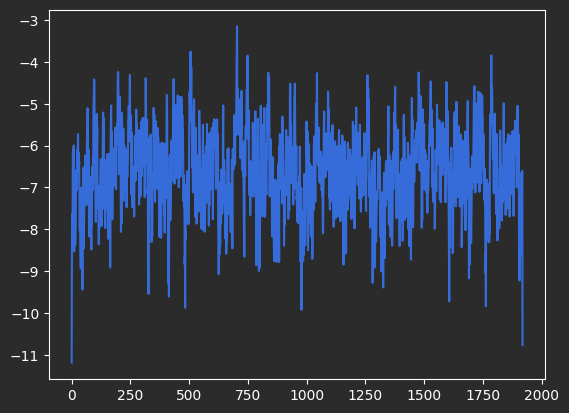

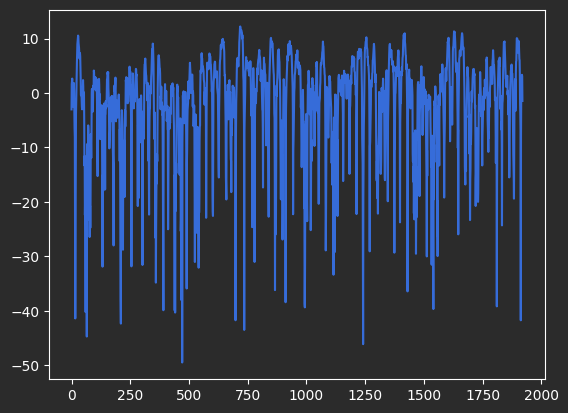

In [32]:
plt.plot(x_prime[0, 2, :])
plt.show()
plt.plot(windowed_data[0, 2, :])
plt.show()

In [18]:
print(net.summary())

audio_encoder_decoder: 27 nodes, 30585837 parameters
  node         sources                    shape
  amp_a        input                      (2, 599, 1200)
  amp_b        amp_a                      (2, 599, 961)
  amp_c        amp_b                      (2, 599, 822)
  freq_fft     input                      (2, 599, 1920)
  freq_fc      freq_fft                   (2, 599, 822)
  stack        amp_c,freq_fc              (2, 599, 1644)
  position     stack                      (2, 599, 1644)
  enc1_attn    position                   (2, 599, 1644)
  enc1_drop    enc1_attn                  (2, 599, 1644)
  enc1_a       enc1_drop                  (2, 599, 1200)
  enc1_b       enc1_a                     (2, 599, 822)
  enc2_attn    enc1_b                     (2, 599, 822)
  enc2_drop    enc2_attn                  (2, 599, 822)
  enc2_a       enc2_drop                  (2, 599, 1200)
  enc2_b       enc2_a                     (2, 599, 822)
  enc3_attn    enc2_b                     (2, 599, 

In [7]:
net.get_node("branch_a_fc")

Node(branch_a_fc <- input)